In [3]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 

# $Defining$ $ the $ $function$

In [58]:
def f(x):
    return np.log10(x) - x + 3
    
def f_def(x):
    return (1/(x* np.log(10))) - 1
    #return (1/x) - 1

# $Newton$ $Raphson$ $Method$

In [74]:
def newton_raphson_iteration(x0, tolerance, max_iteration = 100 ):
    
    itera = []
    x_values = []
    fx_values = []
    error = [] 
    err = 0
    m = 1 #multiple root case 

    i = 0 
    itera.append(i)
    x_values.append(x0)
    fx_values.append(f(x0))
    error.append(err)


    while i < max_iteration:
        fx = f(x0)
        f_prime = f_def(x0)

        if f_prime == 0:
            print("Derivative is zero. Stopping iteration ")   
            break 

        x1 = x0 - (fx/f_prime)
        err = abs(x1 - x0) 
         
        i+= 1
        itera.append(i)
        x_values.append(x1)
        x0 = x1 
        fx_values.append(f(x1))
        error.append(err)

        if err < tolerance:
            break

    newton_ra = pd.DataFrame({
        "Iteration" : itera , 
        "x_n" :x_values ,
        "f(x_n)"  :fx_values,
        "error " :error
    })

    return newton_ra

initial_guess = [(1/4), (1/2), 1]
table_nR = []
for i in initial_guess:
    value = newton_raphson_iteration(i ,1e-8, 100 )
    table_nR.append(value)

for i in range(3):
    print (f"\n For the initial guess x0 = {initial_guess[i]}")
    print(table_nR[i])


 For the initial guess x0 = 0.25
     Iteration       x_n   f(x_n)    error 
0            0  0.250000  2.14794  0.000000
1            1 -2.663733      NaN  2.913733
2            2       NaN      NaN       NaN
3            3       NaN      NaN       NaN
4            4       NaN      NaN       NaN
..         ...       ...      ...       ...
96          96       NaN      NaN       NaN
97          97       NaN      NaN       NaN
98          98       NaN      NaN       NaN
99          99       NaN      NaN       NaN
100        100       NaN      NaN       NaN

[101 rows x 4 columns]

 For the initial guess x0 = 0.5
   Iteration        x_n        f(x_n)        error 
0          0   0.500000  2.198970e+00  0.000000e+00
1          1  17.233526 -1.299715e+01  1.673353e+01
2          2   3.900371 -3.092653e-01  1.333315e+01
3          3   3.552355 -1.839030e-03  3.480158e-01
4          4   3.550260 -7.556722e-08  2.095176e-03
5          5   3.550260  0.000000e+00  8.609956e-08
6          6   3.

C:\Users\mital\AppData\Local\Temp\ipykernel_24200\852386323.py:2: RuntimeWarning: invalid value encountered in log10
  return np.log10(x) - x + 3


# $ Muller$ $Method$

In [75]:
def muller_method(x0, x1, x2 ,tol, max_iteration):
    x = [x0, x1, x2]
    h = 0 
    h_pre = 0 
    lamb = 0 
    lamb_next = 0 
    error = [np.nan, np.nan, np.nan]

    k=2
    k_new = [(k-2), (k-1), k]

    while k < max_iteration:
        h = x[k] - x[k-1]
        h_pre = x[k-1] - x[k-2]

        lamb = h/h_pre
        delta = 1 + lamb

        g = ((lamb**2)*f(x[k-2])) - ((delta**2)*f(x[k-1])) + ((lamb + delta) * f(x[k]))
        c = lamb * ((lamb * f(x[k-2])) - (delta * f(x[k-1])) + f(x[k]))

        denom_1 = g + np.sqrt((g**2) - (4*delta*c*f(x[k])))
        denom_2 = g - np.sqrt((g**2) - (4*delta*c*f(x[k])))

        if abs(denom_1) > abs(denom_2) : 
            lamb_next = -1 * ((2*delta*f(x[k]))/denom_1)
        else:
            lamb_next = -1 * ((2*delta*f(x[k]))/denom_2)
        
        x_new = x[k] + ((x[k] - x[k-1]) * lamb_next)
        x.append(x_new)

        
        err = abs(x_new - x[k])
        error.append(err)
        k = k+1 
        k_new.append(k)
        if err < tol:
            break
    
    muller = pd.DataFrame({
        "iteration" : k_new,
        "x" : x,
        "error" : error
    })

    return muller

table_muller = muller_method((1/4) , (1/2) , (1), 1e-8, 100)
print(table_muller)

   iteration         x         error
0          0  0.250000           NaN
1          1  0.500000           NaN
2          2  1.000000           NaN
3          3  2.157225  1.157225e+00
4          4  3.200565  1.043340e+00
5          5  3.534051  3.334855e-01
6          6  3.550215  1.616423e-02
7          7  3.550260  4.515121e-05
8          8  3.550260  1.022558e-09


# $6^{th}$ $order$ $Method$

In [ ]:
def six_order_method(x0, tol, max_iteration):
    x = [x0]
    error = [np.nan]
    i = 0
    iteration = [i]
    while i < max_iteration:
        fxi = f(x[i])
        fdefxi = f_def(x[i])
        if fdefxi == 0:
            print(f"Stopped: Derivative zero at x = {x[i]}")
            break
        
        w = x[i] - (fxi / fdefxi)
        fw = f(w)
        denominator_z = 2*fxi - 5 * fw
        if denominator_z == 0:
            print(f"Stopped: denominator zero at z step, iteration {i}")
            break
        
        z = w - (fw / fdefxi) * ((2 * fxi - fw) / denominator_z)
        fz = f(z)
        denominator_xnp1 = fxi - 3 * fw
        if denominator_xnp1 == 0:
            print(f"Stopped: denominator zero at x[n+1] step, iteration {i}")
            break
        
        x_new = z - (fz / fdefxi) * ((fxi - fw) / denominator_xnp1)

        x.append(x_new)
        err = abs(x_new - x[i])
        error.append(err)
        i += 1
        iteration.append(i)
        if err < tol:
            break

    six_or = pd.DataFrame({
        "iteration": iteration,
        "x": x,
        "error": error
    })
    return six_or

initial_guess = [(1/4), (1/2), 1]
table_six = []
for i in initial_guess:
    value = six_order_method(i ,1e-8, 100 )
    table_six.append(value)

for i in range(3):
    print (f"\n For the initial guess x0 = {initial_guess[i]}")
    print(table_six[i])


 For the initial guess x0 = 0.25
     iteration     x  error
0            0  0.25    NaN
1            1   NaN    NaN
2            2   NaN    NaN
3            3   NaN    NaN
4            4   NaN    NaN
..         ...   ...    ...
96          96   NaN    NaN
97          97   NaN    NaN
98          98   NaN    NaN
99          99   NaN    NaN
100        100   NaN    NaN

[101 rows x 3 columns]

 For the initial guess x0 = 0.5
     iteration    x  error
0            0  0.5    NaN
1            1  NaN    NaN
2            2  NaN    NaN
3            3  NaN    NaN
4            4  NaN    NaN
..         ...  ...    ...
96          96  NaN    NaN
97          97  NaN    NaN
98          98  NaN    NaN
99          99  NaN    NaN
100        100  NaN    NaN

[101 rows x 3 columns]

 For the initial guess x0 = 1
   iteration        x         error
0          0  1.00000           NaN
1          1  3.55315  2.553150e+00
2          2  3.55026  2.890215e-03
3          3  3.55026  4.440892e-16


C:\Users\mital\AppData\Local\Temp\ipykernel_24200\852386323.py:2: RuntimeWarning: invalid value encountered in log10
  return np.log10(x) - x + 3


# $Plotting$

In [77]:
for i in range(3):
    table_nR[i] = table_nR[i].dropna()
    table_six[i] = table_six[i].dropna()
table_muller = table_muller.dropna()   

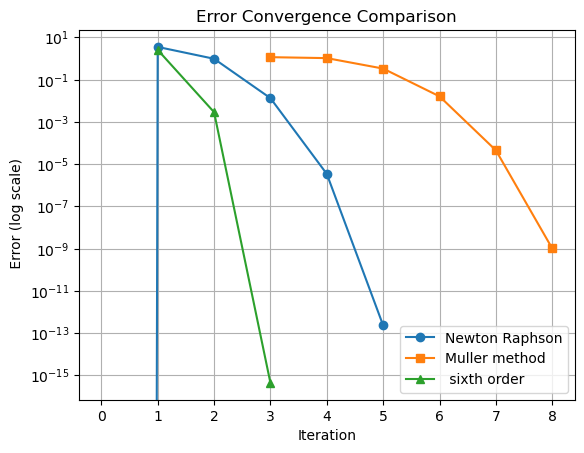

In [80]:
plt.plot(table_nR[2]["error "], label = "Newton Raphson", marker = 'o')
plt.plot(table_muller["error"], label = "Muller method", marker= 's')
plt.plot(table_six[2]["error"], label = " sixth order", marker = '^')

plt.yscale("log")

plt.xlabel("Iteration")
plt.ylabel(" Error (log scale)")
plt.title("Error Convergence Comparison")
plt.legend()
plt.grid()

plt.show ()